# **ANÁLISIS EXPLORATORIO DEL DATASET**

Para este caso utilizaremos el dataset **CDC Diabetes Health Indicators**.

**CONTEXTO:** Los datos provienen de la encuesta telefónica BRFSS 2015 de los Centros para el Control y la Prevención de Enfermedades de Estados Unidos. Cada registro corresponde a una persona encuestada e incluye 21 variables sobre su salud, sus hábitos y su situación socioeconómica. El objetivo del análisis es predecir la variable `Diabetes_binary`, donde 1 indica que la persona tiene diabetes o prediabetes y 0 que no la tiene.

Instalamos la librería que contiene al dataset.

In [1]:
%pip install ucimlrepo

/home/jarvis/universidad/Big_Data/clinical-bigdata-pipeline/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


Importamos las librerías necesarias, `ucimlrepo` para cargar el dataset, `pandas` para el análisis y `matplotlib` para las gráficas.

In [ ]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import matplotlib.pyplot as plt
# fetch dataset 
cdc_diabetes_health_indicators = fetch_ucirepo(id=891)

El dataset separa las variables (`features`) de la variable objetivo (`targets`). Los unimos en un solo DataFrame para que, si más adelante eliminamos registros, ambas partes sigan alineadas.

In [ ]:
X = cdc_diabetes_health_indicators.data.features 
y = cdc_diabetes_health_indicators.data.targets

In [4]:
df = pd.concat([X, y], axis=1)

Veamos el tamaño del dataset y las columnas que lo componen.

In [5]:
df.shape

(253680, 22)

In [6]:
df.columns

Index(['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke',
       'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income',
       'Diabetes_binary'],
      dtype='object')

In [7]:
df.dtypes

HighBP                  int64
HighChol                int64
CholCheck               int64
BMI                     int64
Smoker                  int64
Stroke                  int64
HeartDiseaseorAttack    int64
PhysActivity            int64
Fruits                  int64
Veggies                 int64
HvyAlcoholConsump       int64
AnyHealthcare           int64
NoDocbcCost             int64
GenHlth                 int64
MentHlth                int64
PhysHlth                int64
DiffWalk                int64
Sex                     int64
Age                     int64
Education               int64
Income                  int64
Diabetes_binary         int64
dtype: object

Todas las columnas son enteras, pero no todas significan lo mismo:

- **17 variables binarias** (0 o 1), como `HighBP`, `Smoker` o `PhysActivity`.
- **4 variables ordinales** codificadas con números: `GenHlth` (de 1, salud excelente, a 5, salud mala), `Age` (13 grupos de edad, donde 1 es 18-24 y 13 es 80 o más), `Education` (1 a 6) e `Income` (1 a 8).
- **`BMI`**, el índice de masa corporal, que sí es una medida numérica.

Es importante tener presente que `Age` no son años, sino el grupo de edad al que pertenece la persona.

## **EXPLORACIÓN DE LOS REGISTROS**

In [8]:
df.head(5)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
0,1,1,1,40,1,0,0,0,0,1,...,0,5,18,15,1,0,9,4,3,0
1,0,0,0,25,1,0,0,1,0,0,...,1,3,0,0,0,0,7,6,1,0
2,1,1,1,28,0,0,0,0,1,0,...,1,5,30,30,1,0,9,4,8,0
3,1,0,1,27,0,0,0,1,1,1,...,0,2,0,0,0,0,11,3,6,0
4,1,1,1,24,0,0,0,1,1,1,...,0,2,3,0,0,0,11,5,4,0


In [9]:
df.tail(5)

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
253675,1,1,1,45,0,0,0,0,1,1,...,0,3,0,5,0,1,5,6,7,0
253676,1,1,1,18,0,0,0,0,0,0,...,0,4,0,0,1,0,11,2,4,1
253677,0,0,1,28,0,0,0,1,1,0,...,0,1,0,0,0,0,2,5,2,0
253678,1,0,1,23,0,0,0,0,1,1,...,0,3,0,0,0,1,7,5,1,0
253679,1,1,1,25,0,0,1,1,1,0,...,0,2,0,0,0,0,9,6,2,1


In [10]:
df.describe()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,0.811420,...,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875,0.139333
std,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,0.391175,...,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148,0.346294
min,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000,0.000000
50%,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000,0.000000
75%,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,...,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000,0.000000
max,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000,1.000000


En las columnas binarias, la media que muestra `describe()` equivale a la proporción de personas con el valor en 1. Por ejemplo, el 42.9% de los encuestados tiene presión arterial alta (`HighBP`). En las ordinales, en cambio, la media no tiene una interpretación directa: el promedio de `Age` no son años, sino un punto intermedio entre grupos de edad.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   HighBP                253680 non-null  int64
 1   HighChol              253680 non-null  int64
 2   CholCheck             253680 non-null  int64
 3   BMI                   253680 non-null  int64
 4   Smoker                253680 non-null  int64
 5   Stroke                253680 non-null  int64
 6   HeartDiseaseorAttack  253680 non-null  int64
 7   PhysActivity          253680 non-null  int64
 8   Fruits                253680 non-null  int64
 9   Veggies               253680 non-null  int64
 10  HvyAlcoholConsump     253680 non-null  int64
 11  AnyHealthcare         253680 non-null  int64
 12  NoDocbcCost           253680 non-null  int64
 13  GenHlth               253680 non-null  int64
 14  MentHlth              253680 non-null  int64
 15  PhysHlth              253680 non-n

## **TRATAMIENTO DE VALORES NULOS**

Revisamos si existen valores nulos en el dataset.

In [12]:
df.isnull().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

In [13]:
df.isna().sum()

HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
Diabetes_binary         0
dtype: int64

No hay valores nulos en ninguna columna, así que no es necesario imputar ni eliminar registros por ese motivo. `isnull()` e `isna()` son la misma función en pandas, por lo que las dos celdas devuelven el mismo resultado.

## **VARIABLE OBJETIVO**

Veamos cómo se distribuye `Diabetes_binary`, que es lo que queremos predecir.

In [14]:
df['Diabetes_binary'].value_counts()

Diabetes_binary
0    218334
1     35346
Name: count, dtype: int64

In [15]:
df['Diabetes_binary'].value_counts(normalize=True)

Diabetes_binary
0    0.860667
1    0.139333
Name: proportion, dtype: float64

Las clases están desbalanceadas: solo el 13.93% de las personas encuestadas (35346 de 253680) tiene diabetes o prediabetes. Por eso no usaremos accuracy como métrica, ya que un modelo que siempre prediga 0 acertaría cerca del 86% de las veces sin aprender nada.

## **REGISTROS DUPLICADOS**

Como todas las variables son discretas y la mayoría binarias, es posible que varias personas hayan respondido exactamente lo mismo. Contamos cuántos registros están repetidos.

In [16]:
df.duplicated().sum()

np.int64(24206)

Hay 24206 filas idénticas, el 9.5% del dataset. No son errores de carga, sino personas distintas que dieron las mismas respuestas en la encuesta. Conviene tenerlo en cuenta al separar entrenamiento y prueba, porque un mismo registro puede quedar en los dos conjuntos y hacer que el modelo parezca mejor de lo que es.

También revisamos cuántas combinaciones de respuestas aparecen con las dos etiquetas, es decir, personas que respondieron exactamente lo mismo pero unas tienen diabetes y otras no.

In [17]:
combinaciones = df.groupby(list(X.columns))['Diabetes_binary'].nunique()

(combinaciones > 1).sum()

np.int64(1566)

Hay 1566 combinaciones con las dos etiquetas. Estos casos marcan un límite para cualquier modelo: por más que aprenda, no puede distinguir a dos personas que respondieron exactamente lo mismo. Esto explica que las métricas no puedan acercarse a valores perfectos.

## **RELACIÓN DE LAS VARIABLES CON EL OBJETIVO**

Calculamos la matriz de correlación y luego ordenamos la correlación de cada variable con el objetivo.

In [18]:
df.corr()

,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income,Diabetes_binary
HighBP,1.000000,0.298199,0.098508,0.213748,0.096991,0.129575,0.209361,-0.125267,-0.040555,-0.061266,...,0.017358,0.300530,0.056456,0.161212,0.223618,0.052207,0.344452,-0.141358,-0.171235,0.263129
HighChol,0.298199,1.000000,0.085642,0.106722,0.091299,0.092620,0.180765,-0.078046,-0.040859,-0.039874,...,0.013310,0.208426,0.062069,0.121751,0.144672,0.031205,0.272318,-0.070802,-0.085459,0.200276
CholCheck,0.098508,0.085642,1.000000,0.034495,-0.009929,0.024158,0.044206,0.004190,0.023849,0.006121,...,-0.058255,0.046589,-0.008366,0.031775,0.040585,-0.022115,0.090321,0.001510,0.014259,0.064761
BMI,0.213748,0.106722,0.034495,1.000000,0.013804,0.020153,0.052904,-0.147294,-0.087518,-0.062275,...,0.058206,0.239185,0.085310,0.121141,0.197078,0.042950,-0.036618,-0.103932,-0.100069,0.216843
Smoker,0.096991,0.091299,-0.009929,0.013804,1.000000,0.061173,0.114441,-0.087401,-0.077666,-0.030678,...,0.048946,0.163143,0.092196,0.116460,0.122463,0.093662,0.120641,-0.161955,-0.123937,0.060789
Stroke,0.129575,0.092620,0.024158,0.020153,0.061173,1.000000,0.203002,-0.069151,-0.013389,-0.041124,...,0.034804,0.177942,0.070172,0.148944,0.176567,0.002978,0.126974,-0.076009,-0.128599,0.105816
HeartDiseaseorAttack,0.209361,0.180765,0.044206,0.052904,0.114441,0.203002,1.000000,-0.087299,-0.019790,-0.039167,...,0.031000,0.258383,0.064621,0.181698,0.212709,0.086096,0.221618,-0.099600,-0.141011,0.177282
PhysActivity,-0.125267,-0.078046,0.004190,-0.147294,-0.087401,-0.069151,-0.087299,1.000000,0.142756,0.153150,...,-0.061638,-0.266186,-0.125587,-0.219230,-0.253174,0.032482,-0.092511,0.199658,0.198539,-0.118133
Fruits,-0.040555,-0.040859,0.023849,-0.087518,-0.077666,-0.013389,-0.019790,0.142756,1.000000,0.254342,...,-0.044243,-0.103854,-0.068217,-0.044633,-0.048352,-0.091175,0.064547,0.110187,0.079929,-0.040779
Veggies,-0.061266,-0.039874,0.006121,-0.062275,-0.030678,-0.041124,-0.039167,0.153150,0.254342,1.000000,...,-0.032232,-0.123066,-0.058884,-0.064290,-0.080506,-0.064765,-0.009771,0.154329,0.151087,-0.056584


In [19]:
df.corr()['Diabetes_binary'].sort_values(ascending=False)

Diabetes_binary         1.000000
GenHlth                 0.293569
HighBP                  0.263129
DiffWalk                0.218344
BMI                     0.216843
HighChol                0.200276
Age                     0.177442
HeartDiseaseorAttack    0.177282
PhysHlth                0.171337
Stroke                  0.105816
MentHlth                0.069315
CholCheck               0.064761
Smoker                  0.060789
NoDocbcCost             0.031433
Sex                     0.031430
AnyHealthcare           0.016255
Fruits                 -0.040779
Veggies                -0.056584
HvyAlcoholConsump      -0.057056
PhysActivity           -0.118133
Education              -0.124456
Income                 -0.163919
Name: Diabetes_binary, dtype: float64

La correlación más alta es la de `GenHlth` (0.29), seguida de `HighBP` (0.26), `DiffWalk` (0.22) y `BMI` (0.22). Estas correlaciones son solo orientativas, porque casi todas las variables son binarias u ordinales. Para entender mejor la relación, vemos la tasa de diabetes dentro de cada grupo.

Empezamos por `GenHlth`, la salud que la persona declara tener.

In [20]:
df.groupby('GenHlth')['Diabetes_binary'].mean()

GenHlth
1    0.025166
2    0.071629
3    0.177894
4    0.310105
5    0.378942
Name: Diabetes_binary, dtype: float64

La tasa de diabetes sube de 2.5% entre quienes dicen tener una salud excelente a 37.9% entre quienes la califican como mala. Es una relación mucho más marcada de lo que sugiere la correlación de 0.29.

Ahora la tasa por grupo de edad.

In [21]:
df.groupby('Age')['Diabetes_binary'].mean()

Age
1     0.013684
2     0.018426
3     0.028230
4     0.045287
5     0.065049
6     0.087895
7     0.117352
8     0.138265
9     0.172452
10    0.203703
11    0.218459
12    0.212954
13    0.184818
Name: Diabetes_binary, dtype: float64

La tasa crece con la edad, desde 1.4% en el grupo de 18-24 años hasta 21.8% en el de 70-74 años, y baja un poco en los grupos de mayor edad.

Y la tasa por nivel de ingresos.

In [22]:
df.groupby('Income')['Diabetes_binary'].mean()

Income
1    0.242891
2    0.261903
3    0.223084
4    0.201341
5    0.174014
6    0.145078
7    0.121821
8    0.079604
Name: Diabetes_binary, dtype: float64

La tasa disminuye de forma sostenida desde el 26.2% en el segundo nivel de ingresos hasta el 8% en el más alto, lo que muestra una relación inversa entre ingresos y diabetes.

Por último, comparamos el índice de masa corporal entre quienes tienen diabetes y quienes no.

In [23]:
df.groupby('Diabetes_binary')['BMI'].describe()

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,,,,,,,,
0,218334.0,27.805770,6.291414,12.0,24.0,27.0,31.0,98.0
1,35346.0,31.944011,7.363401,13.0,27.0,31.0,35.0,98.0


In [24]:
(df['BMI'] > 60).sum()

np.int64(805)

El BMI promedio es 27.8 en el grupo sin diabetes y 31.9 en el grupo con diabetes. También hay valores extremos: el máximo es 98 y 805 registros superan 60. Son datos que cada persona reportó en la encuesta, así que los conservamos, pero conviene tenerlos presentes.

## **DISTRIBUCIÓN DE LAS VARIABLES**

Revisamos la distribución de todas las columnas con histogramas.

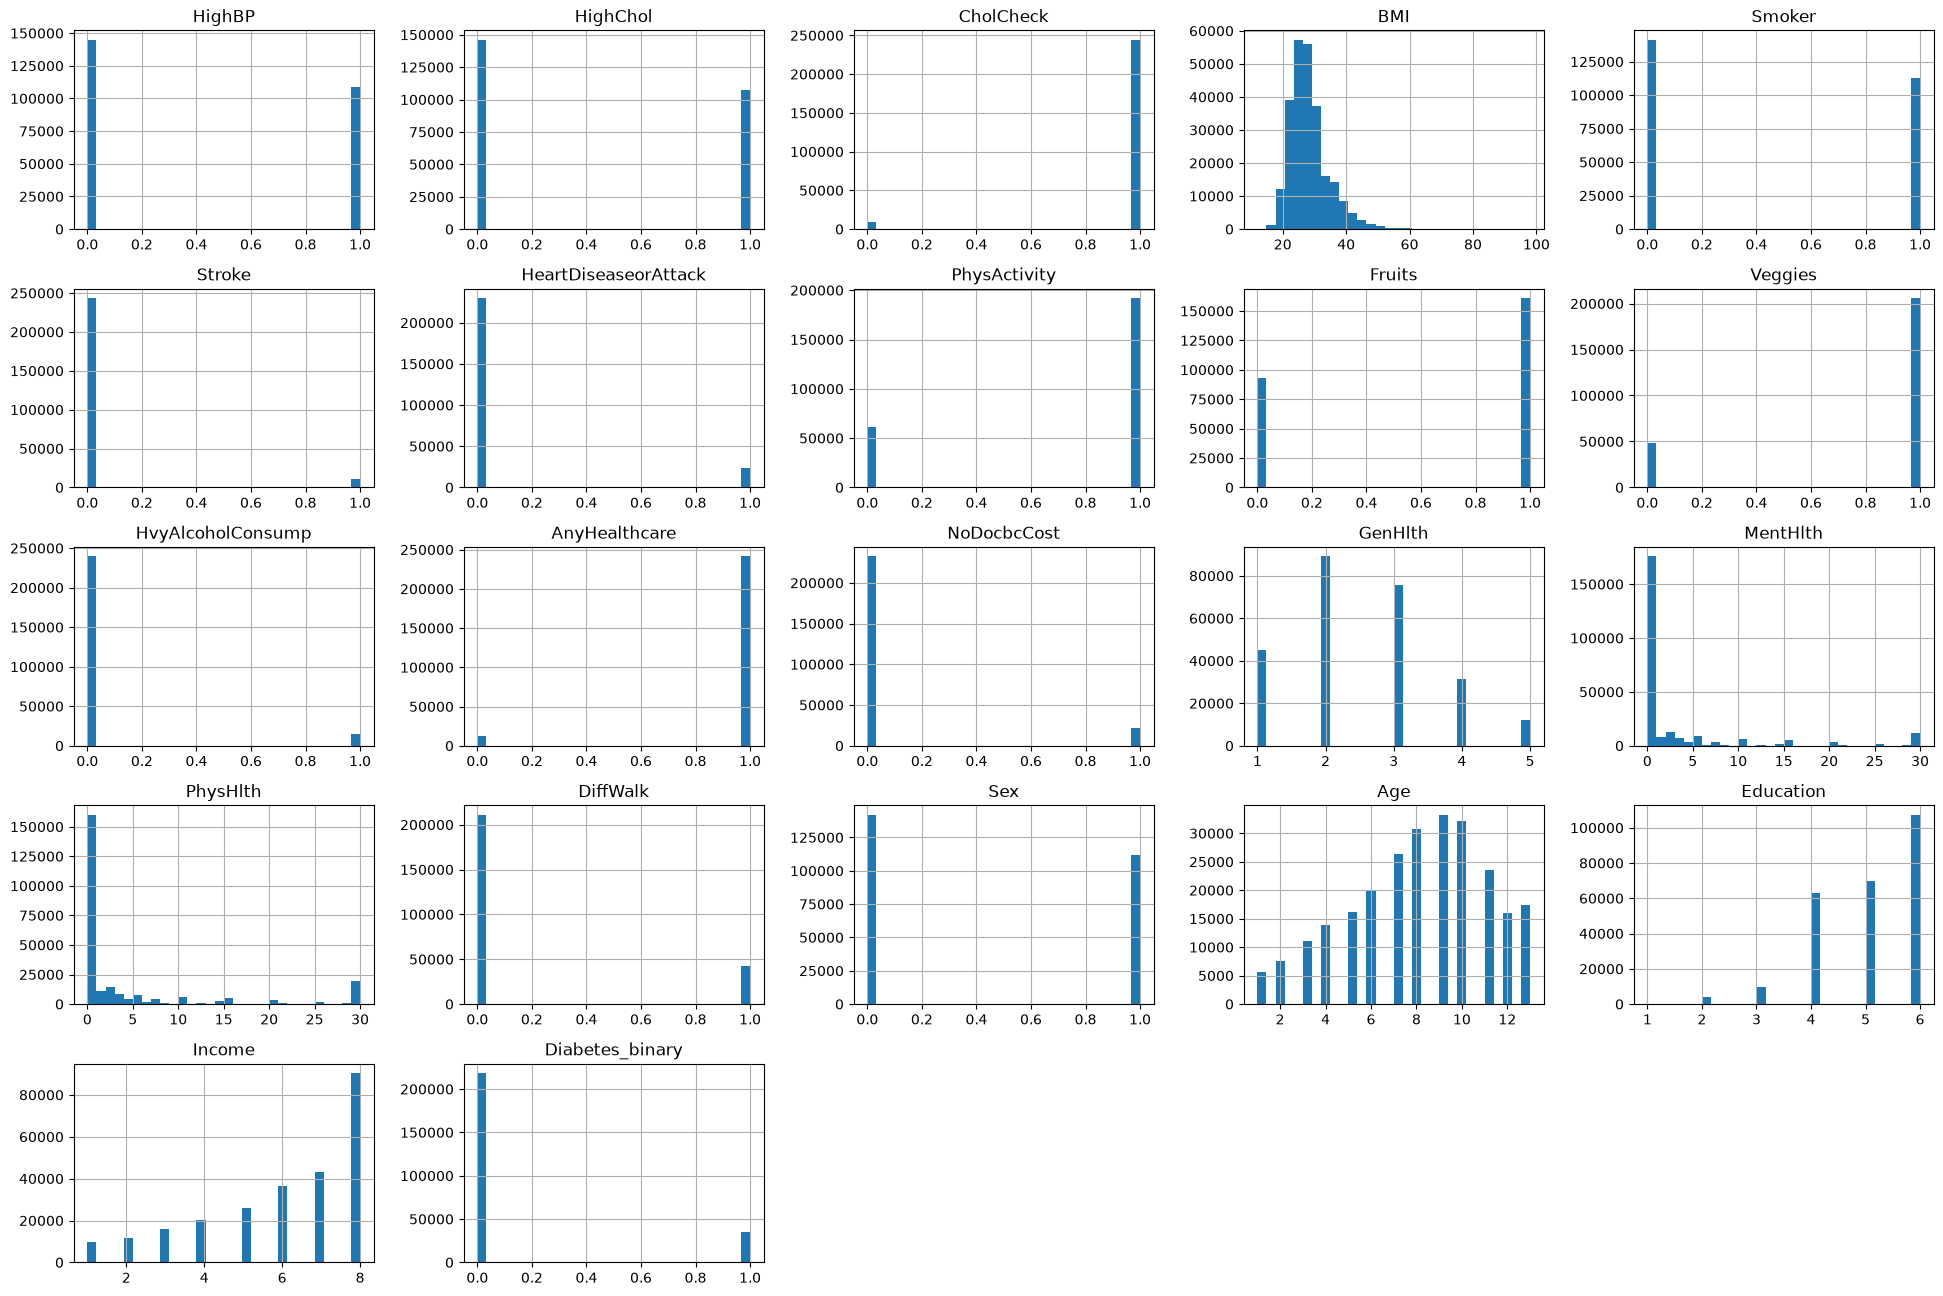

In [25]:
df.hist(bins=30, figsize=(24, 16))
plt.show()

In [26]:
(df[['MentHlth', 'PhysHlth']] == 0).mean()

MentHlth    0.692526
PhysHlth    0.630921
dtype: float64

Las variables binarias muestran solo dos barras, cuya altura indica la proporción de cada valor. `MentHlth` y `PhysHlth`, que cuentan los días de mala salud mental o física del último mes, se concentran en cero: el 69.3% y el 63.1% de las personas respondieron que no tuvieron ningún día malo. `BMI` es la única variable con forma de campana, aunque con una cola larga hacia la derecha.